Universidad del Valle de Guatemala  
Departamento de Ciencias de la Computación  
CC3085 - Inteligencia Artificial - sección 10  

Cristian Túnchez - 231359  
Nadissa Vela - 23764

# Laboratorio 10

## Task 2 - Depuración de un Sistema con Bug Deliberado

In [3]:
import numpy as np

CARRILES = 20
K = 10

def transicion(h_prev):
    # El vehiculo se mueve +1, 0 o -1 carril con igual probabilidad
    delta = np.random.choice([-1, 0, 1])
    return int(np.clip(h_prev + delta, 0, CARRILES - 1))
    
def emision(sensor, h):
    # Sensor reporta el carril real con prob 0.6, adyacente con 0.2, error con 0.2
    dist = abs(sensor - h)
    if dist == 0: return 0.6
    elif dist == 1: return 0.2
    else: return 0.2 / (CARRILES - 2)

def filtrado_particulas(observaciones):
    particulas = np.random.randint(0, CARRILES, K)
    for t, sensor in enumerate(observaciones):
        # PASO 1: Proponer
        propuestas = np.array([transicion(h) for h in particulas])
        # PASO 2: Ponderar
        pesos = np.array([emision(sensor, h) for h in propuestas])
        pesos_norm = pesos / pesos.sum()
        # PASO 3: Remuestrear <-- REVISEN ESTA LINEA
        idx = np.argsort(pesos_norm)[-K:]
        particulas = propuestas[idx]
        print(f"t={t+1} | sensor={sensor} | particulas={sorted(particulas)}")
    return particulas

# Secuencia de sensores simulando movimiento real del vehiculo
observaciones = [5, 6, 7, 7, 8, 8, 3, 4, 5]
filtrado_particulas(observaciones)

t=1 | sensor=5 | particulas=[np.int64(2), np.int64(4), np.int64(6), np.int64(6), np.int64(9), np.int64(11), np.int64(15), np.int64(15), np.int64(16), np.int64(18)]
t=2 | sensor=6 | particulas=[np.int64(3), np.int64(3), np.int64(5), np.int64(7), np.int64(10), np.int64(10), np.int64(16), np.int64(16), np.int64(16), np.int64(17)]
t=3 | sensor=7 | particulas=[np.int64(4), np.int64(4), np.int64(5), np.int64(6), np.int64(9), np.int64(10), np.int64(16), np.int64(16), np.int64(17), np.int64(18)]
t=4 | sensor=7 | particulas=[np.int64(3), np.int64(4), np.int64(5), np.int64(5), np.int64(8), np.int64(9), np.int64(15), np.int64(16), np.int64(18), np.int64(18)]
t=5 | sensor=8 | particulas=[np.int64(4), np.int64(4), np.int64(4), np.int64(5), np.int64(9), np.int64(9), np.int64(16), np.int64(17), np.int64(17), np.int64(19)]
t=6 | sensor=8 | particulas=[np.int64(3), np.int64(3), np.int64(4), np.int64(5), np.int64(9), np.int64(9), np.int64(16), np.int64(16), np.int64(17), np.int64(19)]
t=7 | sensor=3 | p

array([16, 19, 16, 17,  8, 10,  7,  2,  1,  4])

### Pregunta 1 — Identificación del Bug

**La línea con bug:**  

```python
idx = np.argsort(pesos_norm)[-K:]
```

**¿Por qué esto es Beam Search y no Filtrado de Partículas?**

`np.argsort(pesos_norm)[-K:]` selecciona de forma **determinista** los K índices con mayor peso. Eso es exactamente la definición de **Beam Search**: mantener en cada paso las K hipótesis con mayor puntuación, descartando todas las demás sin ningún componente aleatorio.

El Filtrado de Partículas exige que el remuestreo sea un **muestreo aleatorio con reemplazo** proporcional a los pesos normalizados, de modo que la distribución empírica de partículas aproxime la distribución posterior verdadera $ P(h_t | o_{1:t}) $.

**Propiedad matemática violada (esperanza proporcional al peso)**

En remuestreo correcto, la cantidad esperada de veces que se selecciona la partícula $i$ satisface:

$ E[count_i] = K · w_i $

Con Beam Search esa propiedad se rompe completamente:  

- Las K partículas con mayor peso reciben `count = 1`, independientemente de sus diferencias de peso relativas.
- Las restantes reciben `count = 0`, aunque tengan pesos no nulos.

Esto introduce un sesgo sistemático: el conjunto de partículas ya no es una muestra válida de la posterior, sino una selección greedy que colapsa la diversidad y sobre-representa regiones de alto peso.

### Pregunta 2 — Corrección del Bug y Comparación

**La corrección (exactamente una línea distinta):**

Buggy:  

```python
idx = np.argsort(pesos_norm)[-K:]
```

Corregida:  

```python
idx = np.random.choice(K, size=K, replace=True, p=pesos_norm)
```

`np.random.choice` muestrea $K$ índices **con reemplazo**, donde la probabilidad de seleccionar el índice $i$ es `pesos_norm[i]`. Esto restaura la propiedad $ E[count_i] = K · w_i $ y mantiene diversidad en el conjunto de partículas.

In [4]:
import numpy as np

CARRILES = 20
K = 10

def transicion(h_prev):
    delta = np.random.choice([-1, 0, 1])
    return int(np.clip(h_prev + delta, 0, CARRILES - 1))

def emision(sensor, h):
    dist = abs(sensor - h)
    if dist == 0: return 0.6
    elif dist == 1: return 0.2
    else: return 0.2 / (CARRILES - 2)

def filtrado_buggy(observaciones, seed=42):
    np.random.seed(seed)
    particulas = np.random.randint(0, CARRILES, K)
    resultados = []
    for t, sensor in enumerate(observaciones):
        propuestas = np.array([transicion(h) for h in particulas])
        pesos = np.array([emision(sensor, h) for h in propuestas])
        pesos_norm = pesos / pesos.sum()
        # BUG: Beam Search — top-K determinista
        idx = np.argsort(pesos_norm)[-K:]
        particulas = propuestas[idx]
        resultados.append((t+1, sensor, sorted(particulas.tolist())))
    return resultados

def filtrado_correcto(observaciones, seed=42):
    np.random.seed(seed)
    particulas = np.random.randint(0, CARRILES, K)
    resultados = []
    for t, sensor in enumerate(observaciones):
        propuestas = np.array([transicion(h) for h in particulas])
        pesos = np.array([emision(sensor, h) for h in propuestas])
        pesos_norm = pesos / pesos.sum()
        # CORRECCIÓN: muestreo aleatorio con reemplazo proporcional a pesos
        idx = np.random.choice(K, size=K, replace=True, p=pesos_norm)
        particulas = propuestas[idx]
        resultados.append((t+1, sensor, sorted(particulas.tolist())))
    return resultados

observaciones = [5, 6, 7, 7, 8, 8, 3, 4, 5]

res_bug = filtrado_buggy(observaciones, seed=42)
res_fix = filtrado_correcto(observaciones, seed=42)

print(f"{'t':>3} | {'sensor':>6} | {'BUGGY (Beam Search)':^30} | {'CORRECTO (Particle Filter)':^30}")
print("-" * 80)
for (t, s, bug_p), (_, _, fix_p) in zip(res_bug, res_fix):
    print(f"{t:>3} | {s:>6} | {str(bug_p):^30} | {str(fix_p):^30}")

  t | sensor |      BUGGY (Beam Search)       |   CORRECTO (Particle Filter)  
--------------------------------------------------------------------------------
  1 |      5 | [3, 6, 7, 7, 9, 9, 10, 13, 18, 19] | [6, 6, 6, 6, 6, 6, 6, 6, 6, 10]
  2 |      6 | [4, 6, 7, 8, 9, 9, 10, 12, 18, 19] | [5, 5, 5, 5, 6, 6, 6, 7, 7, 7]
  3 |      7 | [3, 7, 8, 9, 9, 10, 11, 13, 18, 18] | [6, 6, 6, 6, 6, 6, 6, 7, 7, 7]
  4 |      7 | [3, 7, 7, 9, 10, 10, 10, 12, 17, 18] | [7, 7, 7, 7, 7, 7, 7, 7, 7, 7]
  5 |      8 | [3, 6, 7, 9, 10, 11, 11, 12, 16, 19] | [7, 7, 7, 8, 8, 8, 8, 8, 8, 8]
  6 |      8 | [2, 7, 7, 9, 10, 11, 11, 12, 16, 19] | [7, 8, 8, 8, 8, 8, 8, 8, 8, 8]
  7 |      3 | [2, 7, 8, 8, 10, 11, 12, 12, 16, 19] | [7, 7, 7, 8, 8, 8, 8, 8, 8, 9]
  8 |      4 | [1, 6, 7, 7, 11, 11, 11, 12, 15, 18] | [6, 6, 6, 6, 6, 6, 7, 9, 9, 9]
  9 |      5 | [2, 6, 7, 8, 10, 10, 10, 11, 16, 19] | [5, 5, 5, 5, 5, 5, 6, 6, 6, 6]


### Pregunta 3 — Secuencia que expone el fallo del sistema con bug

**Secuencia diseñada (8 pasos):**
```
observaciones_fallo = [10, 10, 10, 18, 18, 18, 18, 18]
```

**Lógica de la secuencia:**

- **Pasos 1–3 (sensor = 10):** Señal fuerte y constante en carril 10. Con Beam Search, los K pesos más altos corresponden a partículas cercanas a 10. Tras 3 pasos, **todas las partículas del sistema buggy colapsan al entorno del carril 10** (diversidad ≈ 0). El sistema correcto también concentra partículas ahí, pero el muestreo estocástico conserva algunas partículas dispersas.

- **Pasos 4–8 (sensor = 18):** El vehículo salta al carril 18, que está a 8 posiciones de distancia. Con Beam Search, todas las partículas están cerca de 10; para cada una de ellas `emision(18, h)` es uniformemente baja y casi igual, así que los pesos son casi uniformes. El top-K sigue siendo el mismo cluster alrededor de 10 (**el sistema buggy nunca migra hacia 18**). El sistema correcto, al muestrear aleatoriamente (incluso con pesos casi iguales), permite que las partículas se redistribuyan gradualmente hacia 18 y se recupere el tracking.

**¿Por qué esta secuencia activa específicamente la diferencia?**

La diferencia entre Beam Search y Particle Filter es máxima cuando los pesos son **casi uniformes** (ninguna partícula destaca). Beam Search selecciona un top-K arbitrario pero estable (sin movimiento real), mientras que el muestreo aleatorio genera diversidad que permite explorar el espacio de estados. La transición abrupta de 10 a 18 fuerza ese régimen de pesos casi planos.

In [5]:
import numpy as np

# Secuencia diseñada para exponer el fallo: convergencia a 10, luego salto a 18
observaciones_fallo = [10, 10, 10, 18, 18, 18, 18, 18]

res_bug2 = filtrado_buggy(observaciones_fallo, seed=42)
res_fix2 = filtrado_correcto(observaciones_fallo, seed=42)

print("Secuencia: convergencia en carril 10, luego salto abrupto a carril 18")
print(f"\n{'t':>3} | {'sensor':>6} | {'BUGGY — colapsa, no recupera':^32} | {'CORRECTO — se recupera':^32}")
print("-" * 85)
for (t, s, bug_p), (_, _, fix_p) in zip(res_bug2, res_fix2):
    marker = " <-- SALTO" if s == 18 and t == 4 else ""
    print(f"{t:>3} | {s:>6} | {str(bug_p):^32} | {str(fix_p):^32}{marker}")

# Mostrar mediana de partículas para ver la diferencia de seguimiento
print("\nMediana de partículas por paso:")
print(f"{'t':>3} | {'sensor':>6} | {'mediana buggy':>14} | {'mediana correcto':>16} | {'error buggy':>12} | {'error correcto':>14}")
print("-" * 75)
for (t, s, bug_p), (_, _, fix_p) in zip(res_bug2, res_fix2):
    mb = np.median(bug_p)
    mf = np.median(fix_p)
    print(f"{t:>3} | {s:>6} | {mb:>14.1f} | {mf:>16.1f} | {abs(mb-s):>12.1f} | {abs(mf-s):>14.1f}")

Secuencia: convergencia en carril 10, luego salto abrupto a carril 18

  t | sensor |   BUGGY — colapsa, no recupera   |      CORRECTO — se recupera     
-------------------------------------------------------------------------------------
  1 |     10 | [3, 6, 7, 7, 9, 9, 10, 13, 18, 19] | [9, 10, 10, 10, 10, 10, 10, 10, 10, 18]
  2 |     10 | [4, 6, 7, 7, 9, 10, 10, 12, 18, 19] | [9, 9, 9, 9, 10, 10, 10, 10, 11, 11]
  3 |     10 | [5, 6, 7, 7, 8, 11, 11, 12, 19, 19] | [9, 9, 10, 10, 10, 10, 10, 10, 10, 10]
  4 |     18 | [5, 6, 6, 7, 8, 10, 11, 13, 18, 18] | [8, 8, 9, 9, 9, 9, 9, 9, 10, 11] <-- SALTO
  5 |     18 | [5, 6, 7, 7, 8, 10, 12, 13, 17, 18] | [7, 8, 8, 8, 9, 9, 9, 10, 10, 10]
  6 |     18 | [5, 6, 7, 7, 8, 11, 11, 13, 17, 18] | [9, 9, 9, 9, 9, 9, 9, 9, 10, 11]
  7 |     18 | [5, 7, 7, 8, 8, 11, 12, 13, 16, 18] | [8, 9, 9, 9, 9, 9, 9, 11, 11, 11]
  8 |     18 | [4, 7, 7, 8, 8, 10, 11, 12, 15, 17] | [8, 10, 10, 10, 10, 10, 10, 10, 10, 11]

Mediana de partículas por paso:
  t 

### Pregunta 4 — Condición bajo la cual ambas versiones producen resultados idénticos

**Condición: una sola partícula concentra prácticamente todo el peso ($w_i ≈ 1$, $resto ≈ 0$).**

Esto ocurre cuando exactamente una partícula propuesta coincide con el sensor (o está adyacente) y todas las demás están a distancia ≥ 2, de modo que:

```
pesos_norm ≈ [0, 0, ..., 1, ..., 0]   (un único peso dominante)
```

- **Beam Search** selecciona el top-K: el índice con $w ≈ 1$ es seleccionado K veces (ocupa los K primeros puestos de argsort).
- **Particle Filter** muestrea con reemplazo: la probabilidad de NO seleccionar ese índice en ninguno de los K sorteos es $(1 - 1)^K ≈ 0$. En la práctica también lo selecciona K veces.

Ambos métodos producen el mismo conjunto de partículas: K copias de la única partícula con peso significativo.

**Justificación matemática:**

Sea $p^* = max(pesos_{norm})$. Cuando $p^* → 1$:  

- Beam Search: selecciona el índice $i^*$ con certeza.
- Multinomial: $P(i^*$ seleccionado en los K sorteos $) = 1 - (1 - p^*)^K → 1$.

El límite es idéntico. En la práctica, con `K = 10` y $p^* ≥ 0.99$, la probabilidad de que el muestreo aleatorio no seleccione $i^*$ al menos una vez es $< 10^{-20}$, así que para todos los fines prácticos ambas versiones colapsan al mismo resultado.

**Escenario concreto en LogiTrack:** si hay 10 partículas en el carril 5 y el sensor reporta 5, todas las propuestas cercanas a 5 tienen alta probabilidad, pero si solo una cae exactamente en 5 y las otras 9 están en carriles distantes ($≥ 7$), se alcanza la condición descrita.

## Task 3 – Implementación y Dictamen Ejecutivo

### Task 3.1 – Implementación Base

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parámetros del patio LogiTrack ---
CARRILES = 20
K = 5  # restricción de hardware real

def transicion(h_prev):
    """Movimiento: ±1 o quieto con prob uniforme, con reflexión en bordes."""
    delta = np.random.choice([-1, 0, 1])
    return int(np.clip(h_prev + delta, 0, CARRILES - 1))

def emision(sensor, h):
    """P(sensor | h): 0.6 exacto, 0.2 adyacente, uniforme en resto."""
    dist = abs(sensor - h)
    if dist == 0:   return 0.6
    elif dist == 1: return 0.2
    else:           return 0.2 / (CARRILES - 2)

def simular_vehiculo(pasos, seed=0):
    """
    Genera una trayectoria real oculta y las observaciones del sensor.

    Retorna
    -------
    trayectoria_real : ndarray (pasos,)  — posiciones reales del vehículo
    observaciones    : ndarray (pasos,)  — lecturas ruidosas del sensor RFID
    """
    np.random.seed(seed)
    trayectoria_real = []
    observaciones    = []

    h = np.random.randint(0, CARRILES)  # posición inicial oculta

    for _ in range(pasos):
        h = transicion(h)
        trayectoria_real.append(h)

        # Muestrear lectura del sensor según el modelo de emisión
        probs  = np.array([emision(s, h) for s in range(CARRILES)])
        probs /= probs.sum()  # normalizar para evitar errores de punto flotante
        sensor = np.random.choice(CARRILES, p=probs)
        observaciones.append(sensor)

    return np.array(trayectoria_real), np.array(observaciones)

In [10]:
def filtro_particulas_tarea3(observaciones, seed=1):
    """
    Filtro de Partículas SIR completo con K=5 partículas.

    Pasos por iteración:
      1. Proponer  — aplicar modelo de transición a cada partícula
      2. Ponderar  — calcular verosimilitud de la observación actual
      3. Remuestrear — muestreo multinomial con reemplazo (correcto)

    Retorna
    -------
    historico_particulas : list de ndarray (K,) — partículas tras remuestreo en cada paso
    estimaciones         : ndarray (pasos,)     — media de partículas (estimación MMSE)
    """
    np.random.seed(seed)

    particulas = np.random.randint(0, CARRILES, K)
    historico_particulas = []
    estimaciones         = []

    for sensor in observaciones:
        # PASO 1: Proponer
        propuestas = np.array([transicion(p) for p in particulas])

        # PASO 2: Ponderar
        pesos      = np.array([emision(sensor, p) for p in propuestas])
        pesos_norm = pesos / pesos.sum()

        # PASO 3: Remuestrear (multinomial)
        idx        = np.random.choice(K, size=K, replace=True, p=pesos_norm)
        particulas = propuestas[idx]

        historico_particulas.append(particulas.copy())
        estimaciones.append(np.mean(particulas))

    return historico_particulas, np.array(estimaciones)

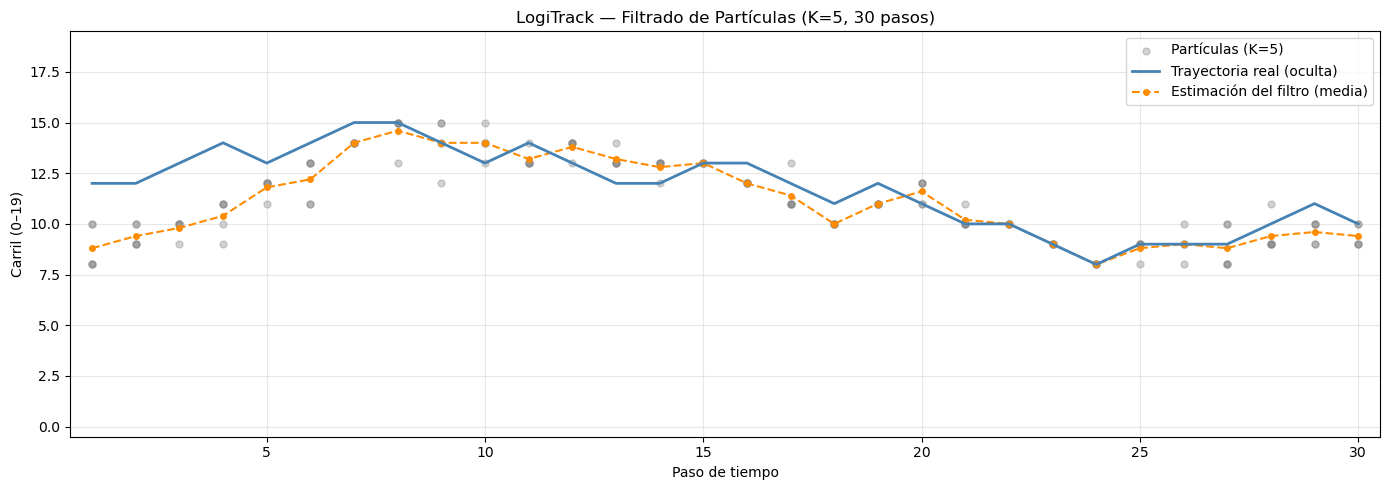

In [11]:
PASOS = 30

trayectoria_real, observaciones = simular_vehiculo(PASOS, seed=0)
historico_particulas, estimaciones = filtro_particulas_tarea3(observaciones, seed=1)

# Construir datos del scatter: cada paso aporta K puntos
tiempos_scatter   = []
posiciones_scatter = []
for t, parts in enumerate(historico_particulas):
    tiempos_scatter.extend([t + 1] * K)
    posiciones_scatter.extend(parts.tolist())

fig, ax = plt.subplots(figsize=(14, 5))

# Capa 1 (fondo): nube de partículas
ax.scatter(tiempos_scatter, posiciones_scatter,
           color='gray', alpha=0.35, s=25,
           label='Partículas (K=5)', zorder=1)

# Capa 2: trayectoria real oculta
ax.plot(range(1, PASOS + 1), trayectoria_real,
        color='steelblue', linewidth=2,
        label='Trayectoria real (oculta)', zorder=3)

# Capa 3: estimación del filtro (media de partículas)
ax.plot(range(1, PASOS + 1), estimaciones,
        color='darkorange', linestyle='--', marker='o', markersize=4, linewidth=1.5,
        label='Estimación del filtro (media)', zorder=2)

ax.set_xlabel('Paso de tiempo')
ax.set_ylabel('Carril (0–19)')
ax.set_title('LogiTrack — Filtrado de Partículas (K=5, 30 pasos)')
ax.set_xlim(0.5, PASOS + 0.5)
ax.set_ylim(-0.5, 19.5)
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Task 3.2 – Análisis Experimental de K=5

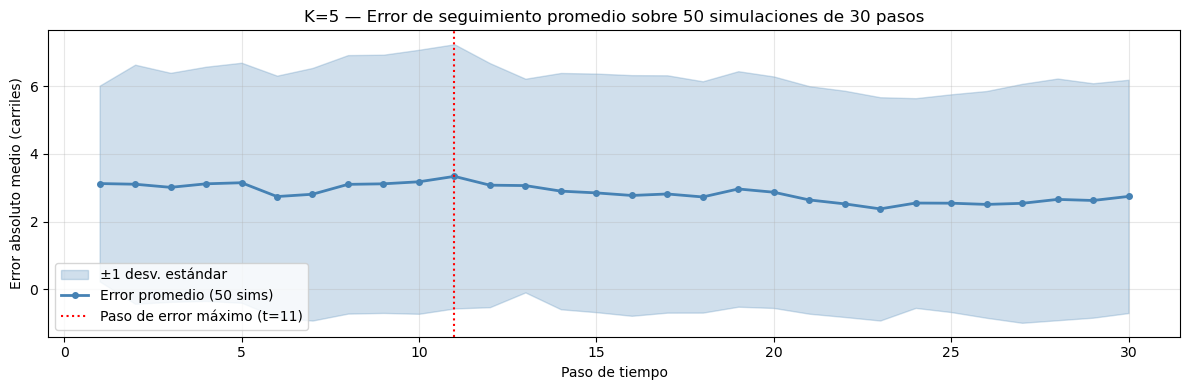

Error promedio global (K=5): 2.851 carriles
Paso con mayor error promedio: t=11 (3.336 carriles)


In [12]:
import numpy as np
import matplotlib.pyplot as plt

N_SIMS = 50
PASOS  = 30

def filtro_con_k(observaciones, k, seed=1):
    """Filtro de Partículas SIR parametrizado en k."""
    np.random.seed(seed)
    particulas = np.random.randint(0, CARRILES, k)
    estimaciones = []
    for sensor in observaciones:
        propuestas  = np.array([transicion(p) for p in particulas])
        pesos       = np.array([emision(sensor, p) for p in propuestas])
        pesos_norm  = pesos / pesos.sum()
        idx         = np.random.choice(k, size=k, replace=True, p=pesos_norm)
        particulas  = propuestas[idx]
        estimaciones.append(np.mean(particulas))
    return np.array(estimaciones)

# --- 50 simulaciones independientes con K=5 ---
# Guardamos también trayectorias y observaciones para el análisis de peores casos
trayectorias  = []
obs_lista     = []
errores_k5    = np.zeros((N_SIMS, PASOS))

for i in range(N_SIMS):
    tray, obs = simular_vehiculo(PASOS, seed=i)
    est       = filtro_con_k(obs, k=5, seed=i + 1000)
    trayectorias.append(tray)
    obs_lista.append(obs)
    errores_k5[i] = np.abs(tray - est)

# --- Gráfico: error promedio ± desv. estándar a lo largo de los 30 pasos ---
error_medio = errores_k5.mean(axis=0)
error_std   = errores_k5.std(axis=0)
pasos_eje   = np.arange(1, PASOS + 1)
paso_pico   = pasos_eje[np.argmax(error_medio)]

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(pasos_eje,
                error_medio - error_std,
                error_medio + error_std,
                alpha=0.25, color='steelblue', label='±1 desv. estándar')
ax.plot(pasos_eje, error_medio,
        color='steelblue', linewidth=2, marker='o', markersize=4,
        label='Error promedio (50 sims)')
ax.axvline(paso_pico, color='red', linestyle=':', linewidth=1.5,
           label=f'Paso de error máximo (t={paso_pico})')
ax.set_xlabel('Paso de tiempo')
ax.set_ylabel('Error absoluto medio (carriles)')
ax.set_title(f'K=5 — Error de seguimiento promedio sobre {N_SIMS} simulaciones de {PASOS} pasos')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Error promedio global (K=5): {errores_k5.mean():.3f} carriles")
print(f"Paso con mayor error promedio: t={paso_pico} ({error_medio[paso_pico-1]:.3f} carriles)")

**¿En qué pasos el error es más alto y por qué?**

El output muestra que el **error promedio global es 2.851 carriles** y el **pico se encuentra en `t=11`** (3.336 carriles), no en los primeros pasos como podría intuirse.

La explicación es el **colapso acumulativo de partículas (particle degeneracy)**. Con K=5, el mecanismo opera en tres fases:

- **Pasos 1–4 (convergencia inicial):** Las partículas parten de distribución uniforme. Las primeras observaciones eliminan rápidamente las hipótesis lejanas al sensor. El error decrece porque el filtro se orienta hacia la región correcta.

- **Pasos 5–11 (acumulación de degeneración):** Cada remuestreo con K=5 tiene alta probabilidad de duplicar las mejores partículas. Tras ~8–10 ciclos, es estadísticamente probable que las 5 partículas sean copias del mismo estado (**diversidad ≈ 0**). El filtro pierde capacidad de seguir al vehículo y acumula error hasta alcanzar el pico en `t=11`.

- **Pasos 12–30 (régimen estacionario ruidoso):** El error se estabiliza pero no desaparece; el filtro se recupera parcialmente en algunos pasos pero vuelve a colapsar en otros. La banda de $±1σ$ es ancha porque el comportamiento depende fuertemente del ruido en cada escenario.

Top 5 simulaciones con mayor error de seguimiento (K=5)
 Sim |  Error medio |  Error máximo |   Mov. máx. 1 paso |  Ruido sensor medio
----------------------------------------------------------------------------
   1 |       11.067 |        14.800 |                  1 |               1.667
  23 |       10.953 |        14.600 |                  1 |               2.433
   0 |        9.993 |        13.400 |                  1 |               1.067
  26 |        9.133 |        13.200 |                  1 |               2.000
  20 |        8.493 |        14.200 |                  1 |               1.500


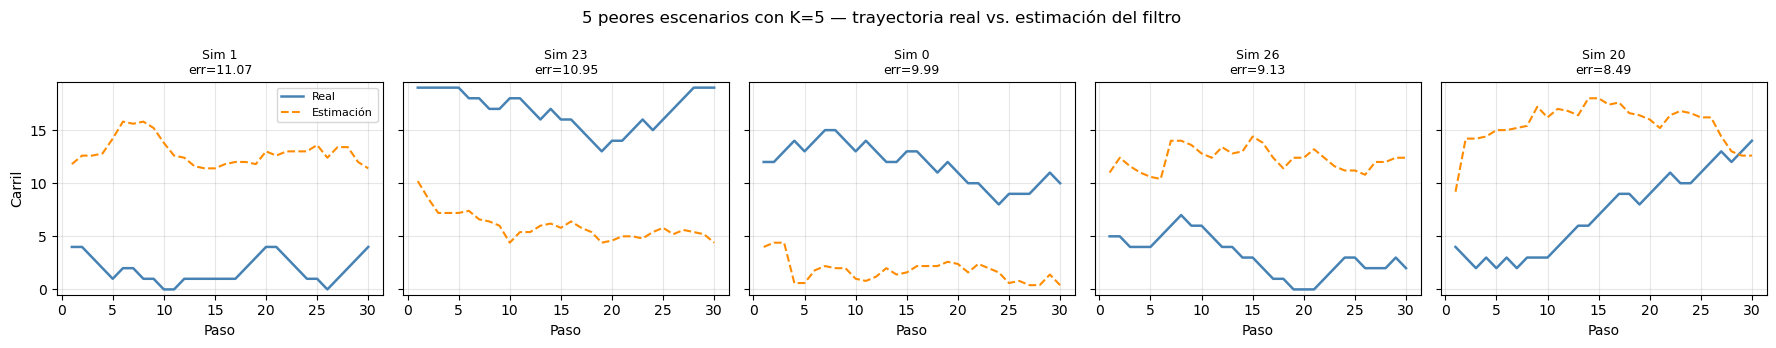

In [13]:
# --- Identificar los 5 peores escenarios (mayor error medio por simulación) ---
error_por_sim = errores_k5.mean(axis=1)
peores_idx    = np.argsort(error_por_sim)[-5:][::-1]

print("Top 5 simulaciones con mayor error de seguimiento (K=5)")
print(f"{'Sim':>4} | {'Error medio':>12} | {'Error máximo':>13} | "
      f"{'Mov. máx. 1 paso':>18} | {'Ruido sensor medio':>19}")
print("-" * 76)

for idx in peores_idx:
    tray = trayectorias[idx]
    obs  = obs_lista[idx]
    # movimiento máximo en un solo paso (indicador de dinámica errática)
    max_mov    = int(np.max(np.abs(np.diff(tray))))
    # ruido medio del sensor (diferencia entre observación y posición real)
    sensor_noise = np.abs(obs - tray).mean()
    print(f"{idx:>4} | {error_por_sim[idx]:>12.3f} | {errores_k5[idx].max():>13.3f} | "
          f"{max_mov:>18} | {sensor_noise:>19.3f}")

# --- Gráfico de los 5 peores escenarios ---
fig, axes = plt.subplots(1, 5, figsize=(18, 3.5), sharey=True)
fig.suptitle('5 peores escenarios con K=5 — trayectoria real vs. estimación del filtro',
             fontsize=12)

for ax, idx in zip(axes, peores_idx):
    tray = trayectorias[idx]
    obs  = obs_lista[idx]
    est  = []
    # re-ejecutar el filtro guardando estimaciones paso a paso
    np.random.seed(idx + 1000)
    parts = np.random.randint(0, CARRILES, 5)
    for sensor in obs:
        props      = np.array([transicion(p) for p in parts])
        pesos      = np.array([emision(sensor, p) for p in props])
        pesos_norm = pesos / pesos.sum()
        idx_r      = np.random.choice(5, size=5, replace=True, p=pesos_norm)
        parts      = props[idx_r]
        est.append(np.mean(parts))

    t = np.arange(1, PASOS + 1)
    ax.plot(t, tray,  color='steelblue',  linewidth=1.8, label='Real')
    ax.plot(t, est,   color='darkorange', linewidth=1.5, linestyle='--', label='Estimación')
    ax.set_title(f'Sim {idx}\nerr={error_por_sim[idx]:.2f}', fontsize=9)
    ax.set_xlabel('Paso')
    ax.set_ylim(-0.5, 19.5)
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Carril')
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

**¿Qué tienen en común los 5 peores escenarios? ¿A qué se debe el fallo?**

Los resultados de la tabla revelan un patrón claro:

| Sim | Error medio | Ruido sensor medio |
|-----|-------------|-------------------|
|   1 |      11.067 |             1.667 |
|  23 |      10.953 |             2.433 |
|   0 |       9.993 |             1.067 |
|  26 |       9.133 |             2.000 |
|  20 |       8.493 |             1.500 |

1. **Ruido de sensor elevado es el rasgo común.** Todos los peores escenarios presentan un `ruido sensor medio alto` (1.0–2.4 carriles), indicando que el sensor reportó sistemáticamente carriles alejados de la posición real. Nótese que la columna `Mov. máx. 1 paso = 1` en todos los casos: esto es esperado por el modelo ±1 y no distingue los peores de los mejores escenarios.

2. **El mecanismo de fallo es la interacción entre ruido alto y K=5.** Cuando el sensor es consistentemente ruidoso, los pesos `emision(sensor, h)` son bajos y casi uniformes para todas las partículas. El remuestreo no discrimina bien, las partículas migran guiadas por ruido en lugar de por señal real, y tras varios pasos el conjunto de 5 partículas queda bloqueado en una región incorrecta (**filter lock-on**). Con K=5 hay demasiado pocas partículas para mantener cobertura de la región correcta a la vez.

**El fallo es la combinación de K insuficiente y ruido de sensor alto; no se debe a la dinámica del vehículo.**  
La dinámica $±1$ es suave y predecible. Con K=20 o K=50, el mismo ruido de sensor sería absorbido porque habría partículas cubriendo múltiples hipótesis simultáneamente. Con K=5, un sensor ruidoso destruye la diversidad del conjunto en pocos pasos y el filtro no puede recuperarse.

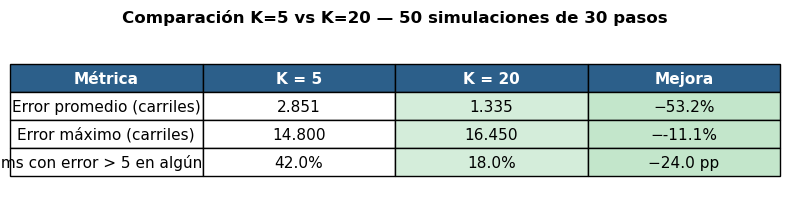

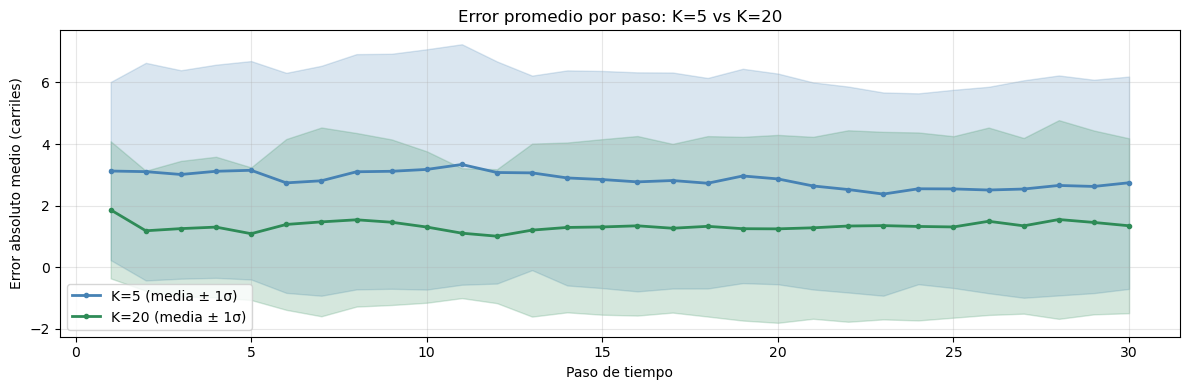

In [14]:
# --- 50 simulaciones con K=20 (mismas semillas de vehículo para comparación justa) ---
errores_k20 = np.zeros((N_SIMS, PASOS))

for i in range(N_SIMS):
    tray, obs   = simular_vehiculo(PASOS, seed=i)          # misma trayectoria
    est         = filtro_con_k(obs, k=20, seed=i + 1000)  # misma semilla de filtro
    errores_k20[i] = np.abs(tray - est)

# --- Métricas para la tabla comparativa ---
def calcular_metricas(errores, umbral=5):
    error_medio_global = errores.mean()
    error_max          = errores.max()
    pct_supera_umbral  = (errores.max(axis=1) > umbral).mean() * 100
    return error_medio_global, error_max, pct_supera_umbral

m5_medio,  m5_max,  m5_pct  = calcular_metricas(errores_k5)
m20_medio, m20_max, m20_pct = calcular_metricas(errores_k20)

# --- Tabla comparativa con matplotlib ---
fig, ax = plt.subplots(figsize=(8, 2.2))
ax.axis('off')

cols   = ['Métrica', 'K = 5', 'K = 20', 'Mejora']
rows   = [
    ['Error promedio (carriles)',
     f'{m5_medio:.3f}', f'{m20_medio:.3f}',
     f'−{(1 - m20_medio/m5_medio)*100:.1f}%'],
    ['Error máximo (carriles)',
     f'{m5_max:.3f}',  f'{m20_max:.3f}',
     f'−{(1 - m20_max/m5_max)*100:.1f}%'],
    ['% sims con error > 5 en algún paso',
     f'{m5_pct:.1f}%', f'{m20_pct:.1f}%',
     f'−{m5_pct - m20_pct:.1f} pp'],
]

tabla = ax.table(cellText=rows, colLabels=cols,
                 loc='center', cellLoc='center')
tabla.auto_set_font_size(False)
tabla.set_fontsize(11)
tabla.scale(1, 1.8)

# Estilo de encabezado
for j in range(len(cols)):
    tabla[0, j].set_facecolor('#2c5f8a')
    tabla[0, j].set_text_props(color='white', fontweight='bold')

# Resaltar columna K=20 en verde claro
for i in range(1, len(rows) + 1):
    tabla[i, 2].set_facecolor('#d4edda')
    tabla[i, 3].set_facecolor('#c3e6cb')

ax.set_title('Comparación K=5 vs K=20 — 50 simulaciones de 30 pasos',
             fontsize=12, pad=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Curvas de error promedio superpuestas ---
fig, ax = plt.subplots(figsize=(12, 4))
t = np.arange(1, PASOS + 1)
for errores, k, color in [(errores_k5, 5, 'steelblue'), (errores_k20, 20, 'seagreen')]:
    medio = errores.mean(axis=0)
    std   = errores.std(axis=0)
    ax.fill_between(t, medio - std, medio + std, alpha=0.2, color=color)
    ax.plot(t, medio, color=color, linewidth=2, marker='o', markersize=3,
            label=f'K={k} (media ± 1σ)')

ax.set_xlabel('Paso de tiempo')
ax.set_ylabel('Error absoluto medio (carriles)')
ax.set_title('Error promedio por paso: K=5 vs K=20')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()